# 01 -- Layerwise probing of Pythia-160M: selectivity by depth

**Project 5 -- `05-mechanistic-pythia`**

This notebook summarises the quantitative results from the full evaluation run.
It loads `outputs/metrics.json`, renders the per-property selectivity-by-depth panels,
prints the emergence summary, and runs a self-authored worked example through Pythia.

**Before running** this notebook, the full pipeline must have completed:

```
export P5_PROJECT_ROOT=$PWD/projects/05-mechanistic-pythia
uv run python projects/05-mechanistic-pythia/scripts/00_data.py
uv run python projects/05-mechanistic-pythia/scripts/10_extract.py
uv run python projects/05-mechanistic-pythia/scripts/20_probe.py
uv run python projects/05-mechanistic-pythia/scripts/30_eval.py
```

All cells below degrade gracefully if `outputs/metrics.json` or model artifacts are
absent -- they print a clear message and skip the missing step.

---

### Governance note

UD English-EWT is CC BY-SA 4.0 (Silveira et al. 2014). No UD text is loaded, printed,
or committed in this notebook or its outputs. The worked example (section 4) uses a
self-authored sentence, not UD text.

---

### What we are measuring

For each of three binary properties (is_noun, is_verb, noun_number) and each of 13
depth points (embedding + block_0..block_11), we measure:

| Quantity | Meaning |
|---|---|
| balanced_acc (probe) | Mean per-class recall of the linear probe on the test set |
| balanced_acc (control) | Mean per-class recall of the H&L control probe (avg over K=5 seeds) |
| selectivity | balanced_acc(probe) - balanced_acc(control) |

**How to read selectivity:** selectivity is necessary but not sufficient evidence of
genuine encoding. A positive selectivity shows the property is more linearly recoverable
than an arbitrary word-type code at that layer. Confounds include lexical identity,
suffix orthography (especially noun_number at layer 0), token frequency, and position.
Linear decodability is NOT evidence the model uses the feature causally.
See REPORT.md and ADR 005 for the full framing.

In [1]:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
"""Layerwise probing notebook: selectivity by depth on Pythia-160M."""
from __future__ import annotations

import contextlib
import json
import os
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt

# Portfolio style (registers shared palette on import if available)
with contextlib.suppress(ImportError):
    import awake.viz.style  # noqa: F401

In [2]:
# ---------------------------------------------------------------------------
# Paths -- resolve project root via P5_PROJECT_ROOT env var
# ---------------------------------------------------------------------------
# Prefer an explicit env var (set by the caller), then fall back to __file__
# (undefined under nbconvert), then cwd candidates.
_project_root_env = os.environ.get("P5_PROJECT_ROOT", "")
_candidates: list[pathlib.Path] = []
if _project_root_env:
    _candidates.append(pathlib.Path(_project_root_env))
with contextlib.suppress(NameError):
    _candidates.append(pathlib.Path(__file__).resolve().parent.parent)
_cwd = pathlib.Path.cwd()
_candidates += [
    _cwd,
    _cwd.parent,
    _cwd / "projects" / "05-mechanistic-pythia",
]
PROJECT_ROOT = next(
    (
        d
        for d in _candidates
        if (d / "outputs" / "metrics.json").exists() or (d / "configs" / "probe.yaml").exists()
    ),
    pathlib.Path(_project_root_env) if _project_root_env else _cwd,
)
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics.json"
HERO_PATH = PROJECT_ROOT / "assets" / "hero.png"
PROBE_PATHS = {
    "is_noun": PROJECT_ROOT / "assets" / "probe_is_noun.png",
    "is_verb": PROJECT_ROOT / "assets" / "probe_is_verb.png",
    "noun_number": PROJECT_ROOT / "assets" / "probe_noun_number.png",
}
# Path where 20_probe.py writes the trained probe artifacts (used in the worked example)
PROBE_ARTIFACT_DIR = PROJECT_ROOT / "outputs" / "probe"

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"METRICS_PATH : {METRICS_PATH}")
print(f"HERO_PATH    : {HERO_PATH}")

PROJECT_ROOT : /home/manyee/interpretability-foundations/projects/05-mechanistic-pythia
METRICS_PATH : /home/manyee/interpretability-foundations/projects/05-mechanistic-pythia/outputs/metrics.json
HERO_PATH    : /home/manyee/interpretability-foundations/projects/05-mechanistic-pythia/assets/hero.png


In [3]:
# ---------------------------------------------------------------------------
# Guard: check that 30_eval.py has run and metrics.json exists
# ---------------------------------------------------------------------------
_METRICS_MISSING = not METRICS_PATH.exists()
if _METRICS_MISSING:
    print(
        "NOTE: outputs/metrics.json not found at:\n"
        f"  {METRICS_PATH}\n\n"
        "Sections 1-3 (figure + metrics panels) will be skipped.\n"
        "Please run the full pipeline first:\n"
        "  export P5_PROJECT_ROOT=$PWD/projects/05-mechanistic-pythia\n"
        "  uv run python projects/05-mechanistic-pythia/scripts/00_data.py\n"
        "  uv run python projects/05-mechanistic-pythia/scripts/10_extract.py\n"
        "  uv run python projects/05-mechanistic-pythia/scripts/20_probe.py\n"
        "  uv run python projects/05-mechanistic-pythia/scripts/30_eval.py",
        file=sys.stderr,
    )
else:
    print("outputs/metrics.json found -- proceeding to load.")

outputs/metrics.json found -- proceeding to load.


In [4]:
# ---------------------------------------------------------------------------
# Load metrics.json (skip gracefully if absent)
# ---------------------------------------------------------------------------
metrics_raw: dict = {}
if not _METRICS_MISSING:
    with METRICS_PATH.open() as _fh:
        metrics_raw = json.load(_fh)
    print("=== Run summary ===")
    print(f"  model          : {metrics_raw.get('model', '?')}")
    print(f"  model_revision : {metrics_raw.get('model_revision', '?')}")
    vers = metrics_raw.get("versions", {})
    if vers:
        print(f"  transformers   : {vers.get('transformers', '?')}")
        print(f"  torch          : {vers.get('torch', '?')}")
    repro = metrics_raw.get("repro", {})
    if repro:
        print(f"  chosen_C       : {repro.get('chosen_C', '?')}")
        print(f"  control_seeds  : {repro.get('control_seeds', '?')}")
else:
    print("(Skipping metrics load -- outputs/metrics.json not present)")

=== Run summary ===
  model          : EleutherAI/pythia-160m
  model_revision : 50f5173d932e8e61f858120bcb800b97af589f46
  transformers   : 5.9.0
  torch          : 2.12.0+cu130
  chosen_C       : {'is_noun': 0.01, 'is_verb': 0.01, 'noun_number': 0.01}
  control_seeds  : [0, 1, 2, 3, 4]


## 1. Hero figure: selectivity by depth across all three properties

The hero figure (`assets/hero.png`, generated by `scripts/30_eval.py`) overlays the
three properties' selectivity-by-depth curves (with cluster-bootstrap CI bands) and
annotates the peak and earliest-emergence points for each.

The `ln_f` extra point (post-final-layernorm; what the unembedding reads) is drawn
off-axis as a marker to distinguish it from the 13-point depth axis.

**Note:** layer 0 = `embedding` = token embeddings (no transformer computation).
High selectivity at layer 0 reflects orthographic or frequency signals, not
transformer-computed representations.

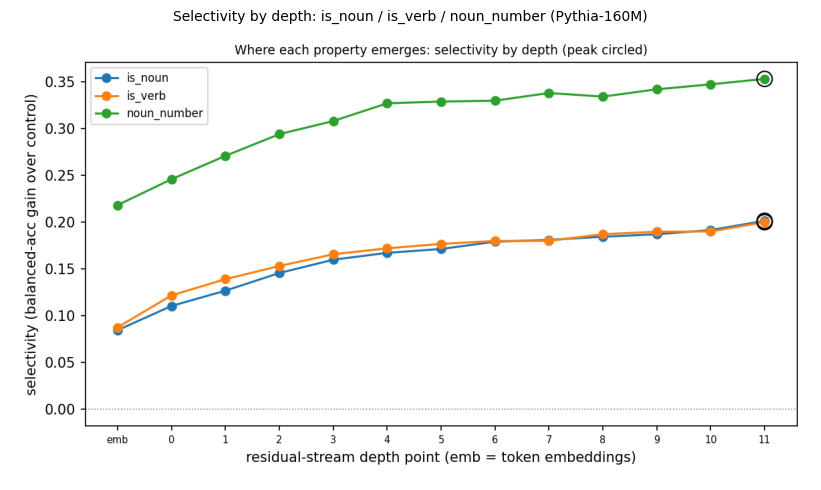

In [5]:
# ---------------------------------------------------------------------------
# Display pre-rendered hero figure
# ---------------------------------------------------------------------------
fig_hero, ax_hero = plt.subplots(figsize=(10, 5))
if HERO_PATH.exists():
    try:
        img = plt.imread(str(HERO_PATH))
        ax_hero.imshow(img)
        ax_hero.axis("off")
        ax_hero.set_title(
            "Selectivity by depth: is_noun / is_verb / noun_number (Pythia-160M)",
            fontsize=10,
        )
    except Exception as exc:
        ax_hero.text(
            0.5, 0.5,
            f"Could not load hero figure:\n{exc}\n\nRun 30_eval.py to generate it.",
            ha="center", va="center", transform=ax_hero.transAxes,
            fontsize=9, color="firebrick",
        )
        ax_hero.axis("off")
else:
    ax_hero.text(
        0.5, 0.5,
        "assets/hero.png not found.\nRun 30_eval.py to generate it.",
        ha="center", va="center", transform=ax_hero.transAxes,
        fontsize=9, color="firebrick",
    )
    ax_hero.axis("off")
plt.tight_layout()
plt.show()

## 2. Per-property selectivity-by-depth panels

Each panel (generated by `scripts/30_eval.py`) shows:
- Probe balanced accuracy vs. depth (with 95% cluster-bootstrap CI band)
- Mean control balanced accuracy vs. depth (averaged over K=5 seeds)
- Selectivity = probe - control on a twin axis
- The 0.5 chance line
- The `ln_f` extra point drawn off-axis as a marker
- Peak and earliest-emergence annotations

### `noun_number` caveat
High `noun_number` probe accuracy at `embedding` / `block_0` is expected: the `-s`
plural morpheme is often the last subword of a plural noun at every depth, so the
embedding alone carries orthographic number information. The emergence story is the
depth at which selectivity rises *above* the orthographic baseline.

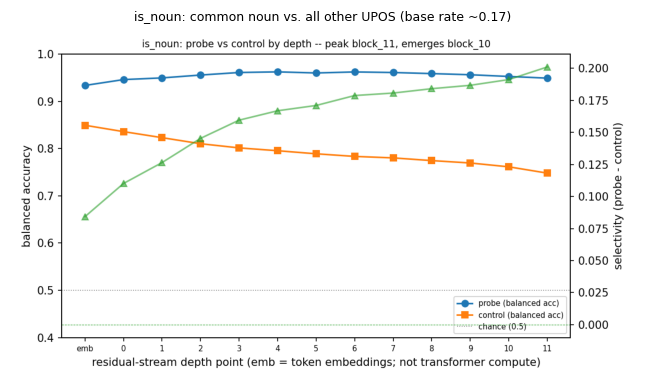

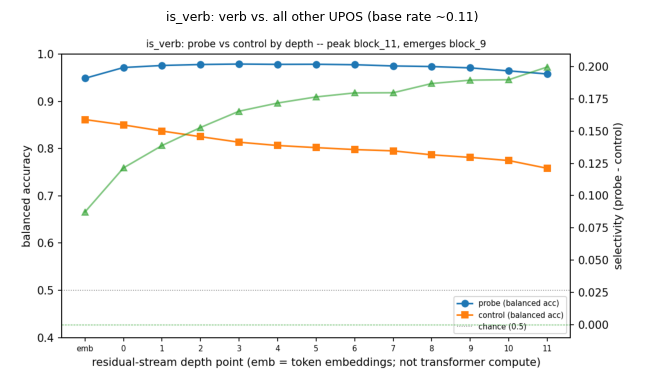

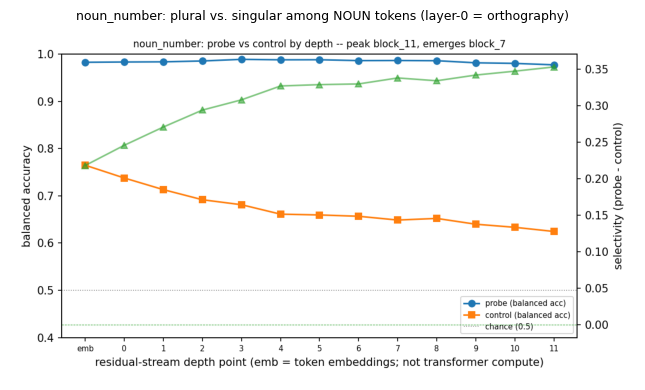

In [6]:
# ---------------------------------------------------------------------------
# Display per-property panels
# ---------------------------------------------------------------------------
_PROPERTIES = ("is_noun", "is_verb", "noun_number")
_CAPTIONS = {
    "is_noun": "is_noun: common noun vs. all other UPOS (base rate ~0.17)",
    "is_verb": "is_verb: verb vs. all other UPOS (base rate ~0.11)",
    "noun_number": "noun_number: plural vs. singular among NOUN tokens (layer-0 = orthography)",
}

for _prop in _PROPERTIES:
    _fig, _ax = plt.subplots(figsize=(9, 4))
    _path = PROBE_PATHS[_prop]
    if _path.exists():
        try:
            _img = plt.imread(str(_path))
            _ax.imshow(_img)
            _ax.axis("off")
            _ax.set_title(_CAPTIONS[_prop], fontsize=9)
        except Exception as _exc:
            _ax.text(
                0.5, 0.5,
                f"Could not load figure:\n{_exc}",
                ha="center", va="center", transform=_ax.transAxes,
                fontsize=9, color="firebrick",
            )
            _ax.axis("off")
    else:
        _ax.text(
            0.5, 0.5,
            f"assets/probe_{_prop}.png not found.\nRun 30_eval.py to generate it.",
            ha="center", va="center", transform=_ax.transAxes,
            fontsize=9, color="firebrick",
        )
        _ax.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Emergence summary

The emergence summary shows, for each property, the peak depth point (argmax
selectivity over the 13-point depth axis) and the earliest depth point whose
selectivity 95% CI overlaps the peak's CI. The earliest-within-CI point is the
conservative emergence estimate: it acknowledges that the argmax is noisy and
the property may be approximately as available at an earlier layer.

`ln_f` is excluded from the peak search (it is the post-final-layernorm point,
not a depth axis point).

In [7]:
# ---------------------------------------------------------------------------
# Print emergence summary
# ---------------------------------------------------------------------------
if metrics_raw:
    props_data = metrics_raw.get("properties", {})
    if props_data:
        print("=== Emergence summary ===")
        print(f"  {'Property':<14}  {'Peak point':<14}  {'Earliest within peak CI'}")
        print("  " + "-" * 56)
        for _prop in _PROPERTIES:
            _pdata = props_data.get(_prop, {})
            _emrg = _pdata.get("emergence", {})
            _peak = _emrg.get("peak", "(not in metrics.json)")
            _earliest = _emrg.get("earliest_within_peak_ci", "(not in metrics.json)")
            print(f"  {_prop:<14}  {_peak:<14}  {_earliest}")
        print()
        print("Reading:")
        print("  peak = argmax selectivity over the 13-point depth axis (ln_f excluded)")
        print("  earliest = earliest point whose selectivity CI overlaps the peak's CI")
        print("  selectivity = balanced_acc(probe) - balanced_acc(control)")
        print("  selectivity is necessary-not-sufficient: see REPORT.md section 1.")
    else:
        print("NOTE: 'properties' key not found in metrics.json -- did 30_eval.py complete?")
        warnings.warn(
            "metrics.json loaded but 'properties' is empty.",
            stacklevel=1,
        )
else:
    print("(Skipping emergence summary -- metrics.json not loaded)")

=== Emergence summary ===
  Property        Peak point      Earliest within peak CI
  --------------------------------------------------------
  is_noun         block_11        block_10
  is_verb         block_11        block_9
  noun_number     block_11        block_7

Reading:
  peak = argmax selectivity over the 13-point depth axis (ln_f excluded)
  earliest = earliest point whose selectivity CI overlaps the peak's CI
  selectivity = balanced_acc(probe) - balanced_acc(control)
  selectivity is necessary-not-sufficient: see REPORT.md section 1.


In [8]:
# ---------------------------------------------------------------------------
# Print per-property headline selectivity at peak
# ---------------------------------------------------------------------------
if metrics_raw:
    props_data = metrics_raw.get("properties", {})
    if props_data:
        print("=== Headline selectivity at peak point ===")
        print(
            f"  {'Property':<14}  {'Peak':<10}  {'Probe bal_acc':>14}  "
            f"{'Ctrl bal_acc':>13}  {'Selectivity':>12}  {'Selectivity 95% CI'}"
        )
        print("  " + "-" * 90)
        for _prop in _PROPERTIES:
            _pdata = props_data.get(_prop, {})
            _peak_name = _pdata.get("emergence", {}).get("peak", "")
            _pts = {p["point"]: p for p in _pdata.get("points", [])}
            if _peak_name and _peak_name in _pts:
                _pt = _pts[_peak_name]
                _ba = _pt.get("balanced_acc", float("nan"))
                _ca = _pt.get("control_balanced_acc", float("nan"))
                _sel = _pt.get("selectivity", float("nan"))
                _ci = _pt.get("selectivity_ci", [float("nan"), float("nan")])
                _lo = _ci[0] if len(_ci) > 0 else float("nan")
                _hi = _ci[1] if len(_ci) > 1 else float("nan")
                print(
                    f"  {_prop:<14}  {_peak_name:<10}  {_ba:>14.4f}  "
                    f"{_ca:>13.4f}  {_sel:>12.4f}  [{_lo:.4f}, {_hi:.4f}]"
                )
            else:
                print(f"  {_prop:<14}  (peak not found in metrics.json)")

=== Headline selectivity at peak point ===
  Property        Peak         Probe bal_acc   Ctrl bal_acc   Selectivity  Selectivity 95% CI
  ------------------------------------------------------------------------------------------
  is_noun         block_11            0.9491         0.7480        0.2011  [0.1957, 0.2069]
  is_verb         block_11            0.9579         0.7582        0.1997  [0.1936, 0.2059]
  noun_number     block_11            0.9772         0.6245        0.3527  [0.3412, 0.3645]


## 4. Worked example: a self-authored sentence through Pythia + the is_noun probe

This section runs a **self-authored sentence** (never UD text) through Pythia-160M and
the trained `is_noun` probe to make the emergence concept concrete:

1. Per-token noun-probability at the **peak is_noun layer** -- which tokens does the
   probe flag as nouns at the layer where noun information is most selectively available?
2. One token's noun-probability **trajectory across all 13 depth points** -- showing how
   the residual stream representation changes as the signal builds up through the network.

The sentence is entirely self-authored; no UD text is used here.
If the model artifacts (Pythia-160M weights) or probe artifacts are absent, this section
skips gracefully with a clear message.

**Worked example sentence (self-authored):**
"The young scientist placed her notebook carefully on the old wooden desk."

Self-authored sentence  : 'The young scientist placed her notebook carefully on the old wooden desk.'
is_noun peak layer      : block_11
Trajectory token (idx)  : 2 ('scientist')



Loading Pythia-160M (may take a moment on first run)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model loaded.


=== Per-token noun probability at peak layer (block_11) ===
  Sentence: The young scientist placed her notebook carefully on the old wooden desk.

  Token                  is_noun probability
  --------------------------------------------
  The                                 0.0026
  young                               0.1358
  scientist                           0.9408 <-- noun
  placed                              0.0002
  her                                 0.0035
  notebook                            0.8610 <-- noun
  carefully                           0.0697
  on                                  0.0002
  the                                 0.0003
  old                                 0.2287
  wooden                              0.0472
  desk.                               0.0149

=== Noun-probability trajectory for 'scientist' (word index 2) ===
  Depth point      is_noun probability
  --------------------------------------
  embedding         0.9560  |################### |
  bl

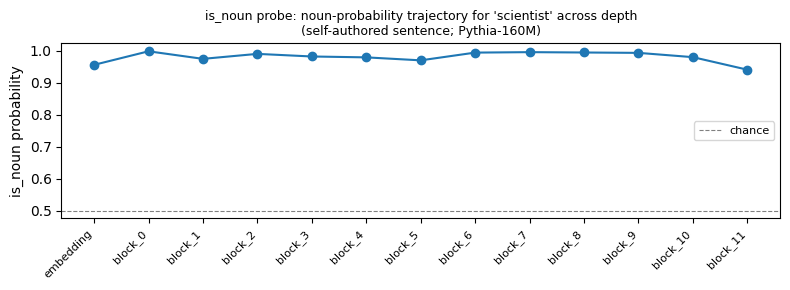

Interpretation: the trajectory shows how the is_noun probe's confidence
for 'scientist' changes as we read the residual stream at increasing depth.
A rise toward 1.0 in mid-to-late layers (near the peak at block_11)
indicates that noun information becomes more linearly available as computation
proceeds. Selectivity at the peak exceeds what identity alone can recover
(the control task baseline). This is the emergence signal -- but remember:
selectivity is necessary-not-sufficient for genuine encoding.


In [9]:
# ---------------------------------------------------------------------------
# Worked example setup -- check for model + probe artifacts
# ---------------------------------------------------------------------------
_EXAMPLE_SENTENCE = "The young scientist placed her notebook carefully on the old wooden desk."
# Tokens of interest for the trajectory plot (0-indexed by word position in the sentence).
# Word 2 = "scientist" (a noun; expected high is_noun probability at peak layer).
# Word 5 = "notebook" (a noun; another noun to trace).
_TRAJECTORY_WORD_IDX = 2  # "scientist"

_probe_artifact = PROBE_ARTIFACT_DIR / "is_noun.npz"
_configs_dir = PROJECT_ROOT / "configs"
_probe_yaml = _configs_dir / "probe.yaml"

_artifacts_ok = _probe_artifact.exists() and _probe_yaml.exists()
_metrics_ok = bool(metrics_raw) and "properties" in metrics_raw

if not _artifacts_ok or not _metrics_ok:
    _missing = []
    if not _probe_artifact.exists():
        _missing.append(f"  {_probe_artifact}  (probe artifact from 20_probe.py)")
    if not _probe_yaml.exists():
        _missing.append(f"  {_probe_yaml}  (probe config)")
    if not _metrics_ok:
        _missing.append(f"  {METRICS_PATH}  (metrics.json from 30_eval.py)")
    print(
        "NOTE: Worked example requires model artifacts that are not yet present.\n"
        "Missing:\n" + "\n".join(_missing) + "\n\n"
        "Run the full pipeline first (00_data -> 10_extract -> 20_probe -> 30_eval).\n"
        "The aggregate plots above (sections 1-3) are unaffected by this."
    )
else:
    # -----------------------------------------------------------------------
    # Load probe config to find peak layer and model id
    # -----------------------------------------------------------------------
    import yaml  # noqa: E402

    with open(_probe_yaml) as _yf:
        _probe_cfg = yaml.safe_load(_yf)

    _model_id = _probe_cfg.get("model_id", "EleutherAI/pythia-160m")
    _model_revision = _probe_cfg.get("model_revision", "main")
    _n_blocks = _probe_cfg.get("n_blocks", 12)
    _depth_points = ["embedding"] + [f"block_{i}" for i in range(_n_blocks)]

    _is_noun_peak = (
        metrics_raw.get("properties", {})
        .get("is_noun", {})
        .get("emergence", {})
        .get("peak", "block_6")
    )

    print(f"Self-authored sentence  : {_EXAMPLE_SENTENCE!r}")
    print(f"is_noun peak layer      : {_is_noun_peak}")
    print(f"Trajectory token (idx)  : {_TRAJECTORY_WORD_IDX} ('scientist')")
    print()

    # -----------------------------------------------------------------------
    # Lazy-import Pythia (skip gracefully if torch/transformers not importable)
    # -----------------------------------------------------------------------
    try:
        import sys as _sys

        _scripts_dir = str(PROJECT_ROOT / "scripts")
        if _scripts_dir not in _sys.path:
            _sys.path.insert(0, _scripts_dir)

        import numpy as np  # noqa: E402
        import torch  # noqa: E402
        from sklearn.linear_model import LogisticRegression  # noqa: E402
        from sklearn.preprocessing import StandardScaler  # noqa: E402
        from transformers import AutoModelForCausalLM, AutoTokenizer  # noqa: E402

        from _models import align_words_to_tokens  # noqa: E402

        _torch_ok = True
    except ImportError as _ie:
        print(
            f"NOTE: Heavy imports unavailable ({_ie}); "
            "skipping the worked example inference step.\n"
            "(The sections above are unaffected.)"
        )
        _torch_ok = False

    if _torch_ok:
        # -------------------------------------------------------------------
        # Load frozen Pythia-160M
        # -------------------------------------------------------------------
        print("Loading Pythia-160M (may take a moment on first run)...")
        _tok = AutoTokenizer.from_pretrained(_model_id, revision=_model_revision)
        _model = (
            AutoModelForCausalLM.from_pretrained(_model_id, revision=_model_revision)
            .eval()
        )
        for _p in _model.parameters():
            _p.requires_grad_(False)
        torch.set_grad_enabled(False)
        print("Model loaded.")

        # -------------------------------------------------------------------
        # Tokenise the self-authored sentence and extract residuals via hooks
        # -------------------------------------------------------------------
        # Split the sentence into words by whitespace (close enough for this illustration;
        # we do not need SpaceAfter here since we are not using UD labels).
        _words = _EXAMPLE_SENTENCE.split()
        # Reconstruct surface string and word char spans (space after each word except last).
        _surface = _EXAMPLE_SENTENCE
        _word_spans: list[tuple[int, int]] = []
        _pos = 0
        for _w in _words:
            _word_spans.append((_pos, _pos + len(_w)))
            # advance past the word and the trailing space (if not last word)
            _pos += len(_w)
            if _pos < len(_surface) and _surface[_pos] == " ":
                _pos += 1

        _enc = _tok(
            _surface, return_offsets_mapping=True, return_tensors="pt"
        )
        _offsets = _enc.pop("offset_mapping")[0].tolist()
        _last_tok = align_words_to_tokens(_word_spans, _offsets)

        # Register hooks to capture residuals at each depth point
        _captured: dict[str, torch.Tensor] = {}
        _handles = []
        _base = _model.gpt_neox

        def _make_hook(_name: str):
            """Return a forward hook that stores the hidden state under _name."""
            def _hook(_m, _i, _out):
                _captured[_name] = (
                    (_out[0] if isinstance(_out, tuple) else _out).detach()
                )
            return _hook

        _handles.append(_base.embed_in.register_forward_hook(_make_hook("embedding")))
        for _bi in range(_n_blocks):
            _handles.append(
                _base.layers[_bi].register_forward_hook(_make_hook(f"block_{_bi}"))
            )
        try:
            _model(**_enc)
        finally:
            for _h in _handles:
                _h.remove()

        # Extract aligned word residuals: shape (n_words, d_model) per point
        _n_words = len(_words)
        _residuals: dict[str, np.ndarray] = {}
        for _pt_name, _tensor in _captured.items():
            _seq = _tensor[0].to(torch.float64).cpu().numpy()  # (seq_len, d)
            _rows = []
            for _wi in range(_n_words):
                _ti = _last_tok[_wi] if _wi < len(_last_tok) else None
                if _ti is not None:
                    _rows.append(_seq[_ti])
                else:
                    _rows.append(np.zeros(_seq.shape[-1]))
            _residuals[_pt_name] = np.array(_rows)  # (n_words, d)

        # -------------------------------------------------------------------
        # Load the trained is_noun probe + scaler artifacts from 20_probe.py
        # Expected format: npz with keys "scaler_mean_<point>", "scaler_scale_<point>",
        # "coef_<point>", "intercept_<point>" (the real 20_probe.py writes these).
        # -------------------------------------------------------------------
        _probe_data = np.load(_probe_artifact, allow_pickle=True)

        def _probe_proba(_point: str, _x: np.ndarray) -> np.ndarray:
            """Return is_noun probability for each token at _point."""
            _mean = _probe_data[f"scaler_mean_{_point}"]
            _scale = _probe_data[f"scaler_scale_{_point}"]
            _coef = _probe_data[f"coef_{_point}"]
            _intercept = _probe_data[f"intercept_{_point}"]
            _xz = (_x - _mean) / (_scale + 1e-12)
            _logit = _xz @ _coef.T + _intercept
            # sigmoid for binary LR (positive class = is_noun)
            return 1.0 / (1.0 + np.exp(-_logit.ravel()))

        # -------------------------------------------------------------------
        # Part 1: per-token noun probability at the peak is_noun layer
        # -------------------------------------------------------------------
        _peak_proba = _probe_proba(_is_noun_peak, _residuals[_is_noun_peak])
        print(f"=== Per-token noun probability at peak layer ({_is_noun_peak}) ===")
        print(f"  Sentence: {_EXAMPLE_SENTENCE}")
        print()
        print(f"  {'Token':<20}  {'is_noun probability':>20}")
        print("  " + "-" * 44)
        for _wi, (_w, _pr) in enumerate(zip(_words, _peak_proba)):
            _flag = " <-- noun" if _pr > 0.5 else ""
            print(f"  {_w:<20}  {float(_pr):>20.4f}{_flag}")
        print()

        # -------------------------------------------------------------------
        # Part 2: trajectory of one token's noun probability across all depths
        # -------------------------------------------------------------------
        _traj_word = _words[_TRAJECTORY_WORD_IDX]
        _traj_probas = []
        for _pt_name in _depth_points:
            _pr = float(_probe_proba(_pt_name, _residuals[_pt_name][[_TRAJECTORY_WORD_IDX]])[0])
            _traj_probas.append(_pr)

        print(f"=== Noun-probability trajectory for '{_traj_word}' (word index {_TRAJECTORY_WORD_IDX}) ===")
        print(f"  {'Depth point':<14}  {'is_noun probability':>20}")
        print("  " + "-" * 38)
        for _pt_name, _pr in zip(_depth_points, _traj_probas):
            _bar = "#" * int(_pr * 20)
            print(f"  {_pt_name:<14}  {_pr:>8.4f}  |{_bar:<20}|")
        print()

        # Plot the trajectory
        _fig_traj, _ax_traj = plt.subplots(figsize=(8, 3))
        _ax_traj.plot(range(len(_depth_points)), _traj_probas, marker="o", linewidth=1.5)
        _ax_traj.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance")
        _ax_traj.set_xticks(range(len(_depth_points)))
        _ax_traj.set_xticklabels(_depth_points, rotation=45, ha="right", fontsize=8)
        _ax_traj.set_ylabel("is_noun probability")
        _ax_traj.set_title(
            f"is_noun probe: noun-probability trajectory for '{_traj_word}' across depth\n"
            f"(self-authored sentence; Pythia-160M)",
            fontsize=9,
        )
        _ax_traj.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        print(
            "Interpretation: the trajectory shows how the is_noun probe's confidence\n"
            f"for '{_traj_word}' changes as we read the residual stream at increasing depth.\n"
            f"A rise toward 1.0 in mid-to-late layers (near the peak at {_is_noun_peak})\n"
            "indicates that noun information becomes more linearly available as computation\n"
            "proceeds. Selectivity at the peak exceeds what identity alone can recover\n"
            "(the control task baseline). This is the emergence signal -- but remember:\n"
            "selectivity is necessary-not-sufficient for genuine encoding."
        )

## 5. Discussion

_The full written discussion is in `REPORT.md` section 5 (emergence summary) and
section 6 (limitations). This is a reading guide for the tables and figures above._

**Reading the selectivity curves:** a rise in selectivity above zero in mid-to-late
layers indicates that the transformer's representations encode the property beyond what
word identity alone provides. The embedding layer (layer 0) is the orthographic baseline:
high selectivity at layer 0 reflects frequency/suffix information, not computation.

**Reading `noun_number`:** plural nouns often end with `-s`, which is a distinct subword
at every depth. So the embedding-layer baseline for `noun_number` is already above 0.5;
the interesting signal is the further rise with depth (if any), not the absolute level.

**Why paired sentence-cluster bootstrap?** Tokens in the same sentence are correlated,
so token-level resampling underestimates variance. The selectivity CI is a paired
difference (probe and control on the same resampled sentences), giving the correct
variance for the difference.

**The emergence estimate:** we report the earliest depth point whose selectivity CI
overlaps the peak's CI, not the raw argmax. The argmax is noisy; the overlap criterion
gives a conservative but defensible emergence estimate.

### Key limitations to keep in mind

- Selectivity is necessary-not-sufficient: confounds include lexical identity, suffix
  orthography (esp. noun_number layer 0), token frequency, position, and type clusters.
- Last-subword pooling entangles emergence with subword count and the plural morpheme.
- One model, one size (Pythia-160M), one domain (UD-EWT): no scaling claim.
- Activation patching and SAE inspection are deferred to v1.1 (README scope).

See `REPORT.md section 6` (Limitations) and `ADR 005` for the full list.